In [1]:
import scanpy as sc 
import os

In [2]:
os.chdir('/Users/iriskwon/Desktop/mouse-cereb-dev/mouse-cereb-dev/')
os.getcwd()

'/Users/iriskwon/Desktop/mouse-cereb-dev/mouse-cereb-dev'

In [4]:
# Command to run Vitessce on RDS file for cellxgene: 
#python -m vitessce launch public/data/cb_dev_annotated_v3.h5ad --static ./vitessce_web

Steps: 
>conda create -n vitessce1 python=3.9
>
>conda activate vitessce1
>
>pip install "vitessce[all]==1.0.11"



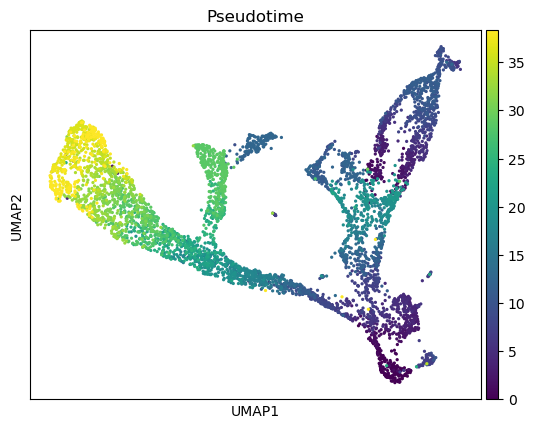

In [18]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper
import scanpy as sc

# Load your h5ad
adata_path = "public/data/cb_dev_annotated_v3.h5ad"
adata = sc.read_h5ad(adata_path)

sc.pl.umap(adata, color="Pseudotime", palette="tab20")

In [4]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper
import scanpy as sc

# Load your h5ad
adata_path = "public/data/combined_alltp_11-2025.h5ad"
adata = sc.read_h5ad(adata_path)

/Users/iriskwon/anaconda3/envs/vitessce-env/lib/python3.9/site-packages/anndata/compat/__init__.py:329: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(


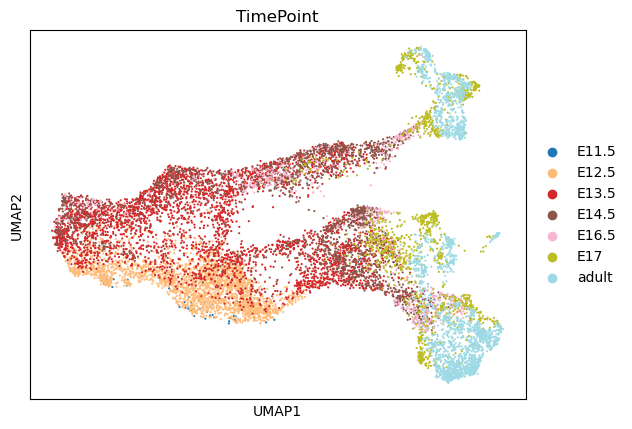

In [5]:
sc.pl.umap(adata, color="TimePoint", palette="tab20")

In [10]:
# extract raw data
raw_X = adata.raw.X
raw_var = adata.raw.var.copy()

In [12]:
if "_index" in raw_var.columns:
    raw_var = raw_var.drop(columns=["_index"])

In [16]:
import anndata as ad

In [17]:
adata.raw = ad.AnnData(
    X=raw_X,
    obs=adata.obs,   # use the parent obs
    var=raw_var
)

In [18]:
adata.raw

In [19]:
adata.write_zarr("public/data/cb_dev_annotated.zarr")

In [20]:
import zarr
z = zarr.open("public/data/cb_dev_annotated.zarr", mode='r')
print(z.tree())

/
 ├── X (12326, 7827) float64
 ├── layers
 ├── obs
 │   ├── DCN
 │   │   ├── categories (4,) object
 │   │   └── codes (12326,) int8
 │   ├── DCN_status
 │   │   ├── categories (2,) object
 │   │   └── codes (12326,) int8
 │   ├── FACS (12326,) float64
 │   ├── RNA_snn_res.1.5
 │   │   ├── categories (8,) object
 │   │   └── codes (12326,) int8
 │   ├── RNA_snn_res.2
 │   │   ├── categories (22,) object
 │   │   └── codes (12326,) int8
 │   ├── RNA_snn_res.4
 │   │   ├── categories (41,) object
 │   │   └── codes (12326,) int8
 │   ├── Replicate
 │   │   ├── categories (3,) object
 │   │   └── codes (12326,) int8
 │   ├── SCT_snn_res.0.3
 │   │   ├── categories (2,) object
 │   │   └── codes (12326,) int8
 │   ├── SCT_snn_res.0.5 (12326,) int32
 │   ├── SCT_snn_res.0.7 (12326,) int32
 │   ├── SCT_snn_res.0.8 (12326,) int32
 │   ├── SCT_snn_res.0.9 (12326,) int32
 │   ├── SCT_snn_res.1 (12326,) int32
 │   ├── SCT_snn_res.1.2 (12326,) int32
 │   ├── SCT_snn_res.2 (12326,) int32
 │   ├──

In [23]:
adata.obs_keys

<bound method AnnData.obs_keys of AnnData object with n_obs × n_vars = 12326 × 7827
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'nCount_SCT', 'nFeature_SCT', 'color', 'TimePoint', 'Replicate', 'Sample', 'percent.blood', 'seurat_clusters', 'SCT_snn_res.0.8', 'RNA_snn_res.2', 'RNA_snn_res.1.5', 'fine_cell_type', 'cell_type', 'cell_type_vague', 'DCN_status', 'branch_intlat', 'meta_neighbor_rel', 'RNA_snn_res.4', 'percent.mt', 'SCT_snn_res.0.3', 'SCT_snn_res.2', 'SCT_snn_res.1', 'FACS', 'DCN', 'final.clusters', 'final.clusters1', 'final.clusters2', 'classes', 'subareas', 'SCT_snn_res.0.5', 'SCT_snn_res.0.7', 'branch', 'SCT_snn_res.0.9', 'SCT_snn_res.1.2'
    var: 'features'
    uns: 'neighbors', 'TimePoint_colors'
    obsm: 'X_mnn', 'X_umap'
    obsp: 'distances'>

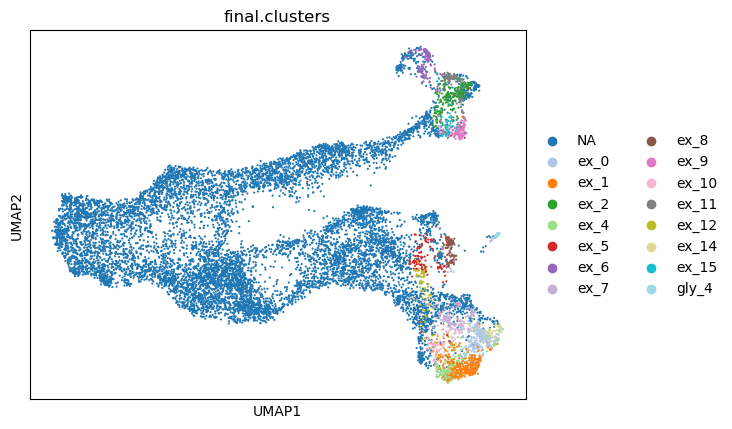

In [43]:
sc.pl.umap(adata, color="final.clusters", palette="tab20")

Text(0.5, 1.0, 'UMAP of Final Clusters')

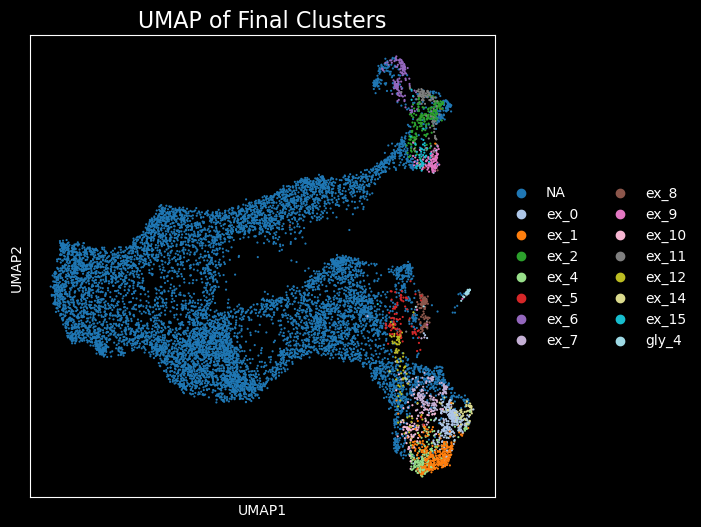

In [47]:
import scanpy as sc
import matplotlib.pyplot as plt

# Set black background for everything
plt.style.use("dark_background")

# Create a figure
fig, ax = plt.subplots(figsize=(6,6), facecolor="black")

# Plot UMAP on that axis
sc.pl.umap(
    adata,
    color="final.clusters",
    palette="tab20",
    ax=ax,
    show=False  # important: do not display yet
)

# Add a title
ax.set_title("UMAP of Final Clusters", color="white", fontsize=16)

# Save figure
#fig.savefig("umap_final_clusters.png", dpi=300, facecolor="black", bbox_inches="tight")
#plt.close(fig)

In [ ]:
'fine_cell_type', 'cell_type', 'cell_type_vague', 'DCN_status', 'branch_intlat', 'meta_neighbor_rel', 'RNA_snn_res.4', 'percent.mt', 'SCT_snn_res.0.3', 'SCT_snn_res.2', 'SCT_snn_res.1', 'FACS', 'DCN', 'final.clusters', 'final.clusters1', 'final.clusters2', 'classes', 'subareas', 'SCT_snn_res.0.5', 'SCT_snn_res.0.7', 'branch', 'SCT_snn_res.0.9', 'SCT_snn_res.1.2'

In [38]:
from vitessce import VitessceConfig, ViewType as vt, CoordinationType as ct, AnnDataWrapper
import scanpy as sc
# Create Vitessce config
vc = VitessceConfig(schema_version="1.0.15", name="Mouse Cerebellum Development")
zarr_path = "public/data/cb_dev_annotated.zarr"

dataset = vc.add_dataset("CB Dev").add_object(AnnDataWrapper(
    adata_path = zarr_path,
    obs_feature_matrix_path="X",
    obs_embedding_paths=["obsm/X_umap"],
    obs_embedding_names = ["UMAP"],   
    obs_set_paths=["obs/TimePoint", "obs/Sample", "obs/fine_cell_type", "obs/cell_type", 
                   "obs/cell_type_vague", "obs/final.clusters", "obs/subareas"],  # categorical
    obs_set_names=["TimePoint", "Sample", "Fine Cell Type", "Cell Type", "Vague Cell Type", 
                   "Final Clusters", "Subareas"]
    # obs_continuous_paths=["obs/Pseudotime"],                    # continuous
    # obs_continuous_names=["Pseudotime"]
))

# === Add views ===
desc = vc.add_view(vt.DESCRIPTION, dataset=dataset).set_props(
    description="Developing Mouse Cerebellum Coronal Slice\n Combined all timepoints. November 2025 data.")
scatter = vc.add_view(vt.SCATTERPLOT, dataset=dataset, mapping="UMAP")  # can use UMAP as spatial
cell_sets = vc.add_view(vt.OBS_SETS, dataset=dataset)
genes = vc.add_view(vt.FEATURE_LIST, dataset=dataset)
#heatmap = vc.add_view(vt.HEATMAP, dataset=dataset)

# Layout
vc.layout(desc / ((cell_sets / genes) | scatter));

# Render the widget in Jupyter
vc.widget()


VitessceWidget(config={'version': '1.0.15', 'name': 'Mouse Cerebellum Development', 'description': '', 'datase…

In [9]:
adata.obsm.keys()

KeysView(AxisArrays with keys: X_pca, X_umap)

In [40]:
path = "/Users/iriskwon/Desktop/mouse-cereb-dev/"
os.chdir(path)
# verify the change
print("New working directory:", os.getcwd())

New working directory: /Users/iriskwon/Desktop/mouse-cereb-dev


In [41]:
# Export your config to a Python dictionary
config_dict = vc.to_dict(base_url="configs_for_vitessce")

import json 

# Write it to a JS file for your React app
with open("configs_for_vitessce/cb_dev_all_tps-config.js", "w") as f:
    f.write("export const cbDevAllTpConfig = ")
    json.dump(config_dict, f, indent=2)
    f.write(";")
